In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from backtest_functions_v3 import *

# Import Data

In [3]:
full = pd.read_parquet('btcusd_daily_price_indicators.parquet', engine='pyarrow')
full['EMA_5'] = full['Close'].ewm(span=5, adjust=False).mean()
full

,Open,High,Low,Close,Volume,return_forward,SMA_10,SMA_20,SMA_50,SMA_100,...,ATR_7,ATR_14,ATR_21,Upper_Band_10,Middle_Band_10,Lower_Band_10,Upper_Band_20,Middle_Band_20,Lower_Band_20,EMA_5
Timestamp,,,,,,,,,,,,,,,,,,,,,
2012-01-01,4.58,4.84,4.58,4.84,10.000000,0.033058,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.840000
2012-01-02,4.84,5.00,4.84,5.00,10.100000,0.058000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.893333
2012-01-03,5.00,5.32,5.00,5.29,107.085281,0.052930,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.025556
2012-01-04,5.29,5.57,4.93,5.57,107.233260,0.152603,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.207037
2012-01-05,5.57,6.46,5.57,6.42,70.328742,-0.003115,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.611358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,95606.00,97337.00,93282.00,94168.00,2060.503361,-0.000212,97794.0,99659.95,95484.02,80722.52,...,2885.612752,2665.555647,2534.274232,104384.571144,97794.0,91203.428856,106787.872516,99659.95,92532.027484,96804.979047
2024-12-28,94159.00,94159.00,94118.00,94148.00,0.015052,-0.006277,96590.1,99369.00,95847.74,81046.50,...,2480.525216,2478.730243,2415.975460,100434.378080,96590.1,92745.821920,106887.386423,99369.00,91850.613577,95919.319365
2024-12-29,95021.00,95124.00,92868.00,93557.00,762.959106,-0.000556,96208.3,99173.45,96184.44,81349.96,...,2448.450185,2462.820940,2408.357580,100406.971223,96208.3,92009.628777,107073.214793,99173.45,91273.685207,95131.879577


In [4]:
D = full.loc['2021-01-01':'2024-12-31']
D

,Open,High,Low,Close,Volume,return_forward,SMA_10,SMA_20,SMA_50,SMA_100,...,ATR_7,ATR_14,ATR_21,Upper_Band_10,Middle_Band_10,Lower_Band_10,Upper_Band_20,Middle_Band_20,Lower_Band_20,EMA_5
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-01,28912.47,29700.00,28720.00,29130.21,9211.491621,0.133747,26405.506,24132.4480,20545.7702,16492.3262,...,1514.214905,1397.485125,1287.263520,30462.625712,26405.506,22348.386288,30130.588656,24132.4480,18134.307344,28082.640578
2021-01-02,29131.88,33333.00,28947.70,33026.28,13444.106964,-0.008069,27346.608,24824.8935,20881.0034,16716.0582,...,1924.369919,1610.900473,1434.789067,32575.106705,27346.608,22118.109295,31530.805681,24824.8935,18118.981319,29730.520385
2021-01-03,33032.97,34800.00,30000.00,32759.78,17953.046058,-0.048455,28290.464,25501.5200,21217.7990,16936.4064,...,2335.174216,1838.693297,1595.037206,33676.855662,28290.464,22904.072338,32534.565336,25501.5200,18468.474664,30740.273590
2021-01-04,32758.87,33872.26,27734.00,31172.41,22515.069434,0.073631,28973.400,26083.6480,21522.8982,17140.9244,...,2878.472185,2145.805204,1811.381149,33896.511110,28973.400,24050.288890,32968.984944,26083.6480,19198.311056,30884.319060
2021-01-05,31179.50,33518.77,29936.26,33467.68,12973.909376,0.056172,29758.111,26726.3130,21858.0398,17368.2413,...,2979.049016,2248.426975,1895.720618,34793.661721,29758.111,24722.560279,33845.161140,26726.3130,19607.464860,31745.439373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,95606.00,97337.00,93282.00,94168.00,2060.503361,-0.000212,97794.000,99659.9500,95484.0200,80722.5200,...,2885.612752,2665.555647,2534.274232,104384.571144,97794.000,91203.428856,106787.872516,99659.9500,92532.027484,96804.979047
2024-12-28,94159.00,94159.00,94118.00,94148.00,0.015052,-0.006277,96590.100,99369.0000,95847.7400,81046.5000,...,2480.525216,2478.730243,2415.975460,100434.378080,96590.100,92745.821920,106887.386423,99369.0000,91850.613577,95919.319365
2024-12-29,95021.00,95124.00,92868.00,93557.00,762.959106,-0.000556,96208.300,99173.4500,96184.4400,81349.9600,...,2448.450185,2462.820940,2408.357580,100406.971223,96208.300,92009.628777,107073.214793,99173.4500,91273.685207,95131.879577


In [5]:
D.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'return_forward', 'SMA_10',
       'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200', 'EMA_10', 'EMA_20', 'EMA_50',
       'EMA_100', 'EMA_200', 'MACD_12_26', 'Signal_Line_9', 'MACD_Histogram',
       'ADX', '+DI', '-DI', 'RSI_14', 'ATR_7', 'ATR_14', 'ATR_21',
       'Upper_Band_10', 'Middle_Band_10', 'Lower_Band_10', 'Upper_Band_20',
       'Middle_Band_20', 'Lower_Band_20', 'EMA_5'],
      dtype='object')

# Buy & Hold Return (2021-2024)

In [6]:
df = D.copy()
# df = df.loc['2024-01-01':'2024-12-31']
df['signal'] = 1

df

,Open,High,Low,Close,Volume,return_forward,SMA_10,SMA_20,SMA_50,SMA_100,...,ATR_14,ATR_21,Upper_Band_10,Middle_Band_10,Lower_Band_10,Upper_Band_20,Middle_Band_20,Lower_Band_20,EMA_5,signal
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-01,28912.47,29700.00,28720.00,29130.21,9211.491621,0.133747,26405.506,24132.4480,20545.7702,16492.3262,...,1397.485125,1287.263520,30462.625712,26405.506,22348.386288,30130.588656,24132.4480,18134.307344,28082.640578,1
2021-01-02,29131.88,33333.00,28947.70,33026.28,13444.106964,-0.008069,27346.608,24824.8935,20881.0034,16716.0582,...,1610.900473,1434.789067,32575.106705,27346.608,22118.109295,31530.805681,24824.8935,18118.981319,29730.520385,1
2021-01-03,33032.97,34800.00,30000.00,32759.78,17953.046058,-0.048455,28290.464,25501.5200,21217.7990,16936.4064,...,1838.693297,1595.037206,33676.855662,28290.464,22904.072338,32534.565336,25501.5200,18468.474664,30740.273590,1
2021-01-04,32758.87,33872.26,27734.00,31172.41,22515.069434,0.073631,28973.400,26083.6480,21522.8982,17140.9244,...,2145.805204,1811.381149,33896.511110,28973.400,24050.288890,32968.984944,26083.6480,19198.311056,30884.319060,1
2021-01-05,31179.50,33518.77,29936.26,33467.68,12973.909376,0.056172,29758.111,26726.3130,21858.0398,17368.2413,...,2248.426975,1895.720618,34793.661721,29758.111,24722.560279,33845.161140,26726.3130,19607.464860,31745.439373,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,95606.00,97337.00,93282.00,94168.00,2060.503361,-0.000212,97794.000,99659.9500,95484.0200,80722.5200,...,2665.555647,2534.274232,104384.571144,97794.000,91203.428856,106787.872516,99659.9500,92532.027484,96804.979047,1
2024-12-28,94159.00,94159.00,94118.00,94148.00,0.015052,-0.006277,96590.100,99369.0000,95847.7400,81046.5000,...,2478.730243,2415.975460,100434.378080,96590.100,92745.821920,106887.386423,99369.0000,91850.613577,95919.319365,1
2024-12-29,95021.00,95124.00,92868.00,93557.00,762.959106,-0.000556,96208.300,99173.4500,96184.4400,81349.9600,...,2462.820940,2408.357580,100406.971223,96208.300,92009.628777,107073.214793,99173.4500,91273.685207,95131.879577,1


Overall Annual Return: 48.98%
Overall Annual Sharpe Ratio: 0.7761
Maximum Drawdown: -76.46 %
Win/Loss Ratio: 1.0726
Alpha: 0.0
Beta: 1.0

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.846187    0.845068          1.0           0.0       1.001325
1  2022      -0.860538    0.615854          1.0           0.0      -1.397309
2  2023       1.063851    0.467779          1.0           0.0       2.274261
3  2024       0.908517    0.527168          1.0           0.0       1.723391


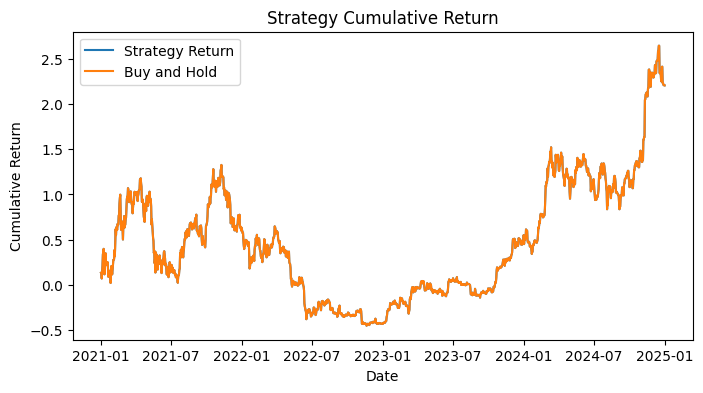

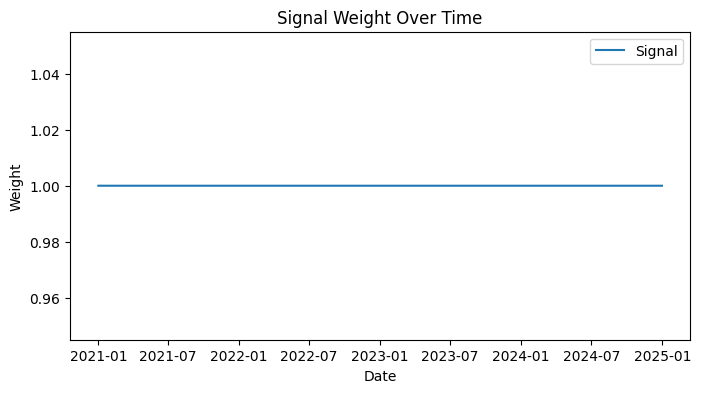

In [7]:
run_backtest(df)

## Annualized return 48.98% 
## Sharpe 0.7761

# Golden/Death Cross

## Golden Cross Only

In [10]:
long = D[(D['SMA_50'] > D['SMA_200']) ] # & (D['Close'] > D['EMA_5'])
condition = D.index.isin(long.index)

df = pd.DataFrame(np.where(condition, 1, 0), index=D.index, columns=['signal'])
df


,signal
Timestamp,
2021-01-01,1
2021-01-02,1
2021-01-03,1
2021-01-04,1
2021-01-05,1
...,...
2024-12-27,1
2024-12-28,1
2024-12-29,1


Overall Annual Return: 41.1%
Overall Annual Sharpe Ratio: 0.8146
Maximum Drawdown: -55.77 %
Win/Loss Ratio: 1.1057
Alpha: 0.103
Beta: 0.6389

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.496962    0.773523     0.837177     -0.211447       0.642465
1  2022      -0.088062    0.092498     0.022066     -0.069074      -0.952040
2  2023       0.438481    0.416471     0.789219     -0.401130       1.052850
3  2024       0.795605    0.488825     0.858935      0.015248       1.627587


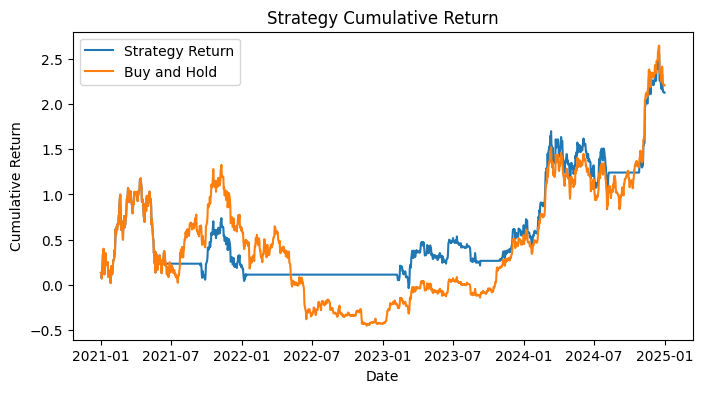

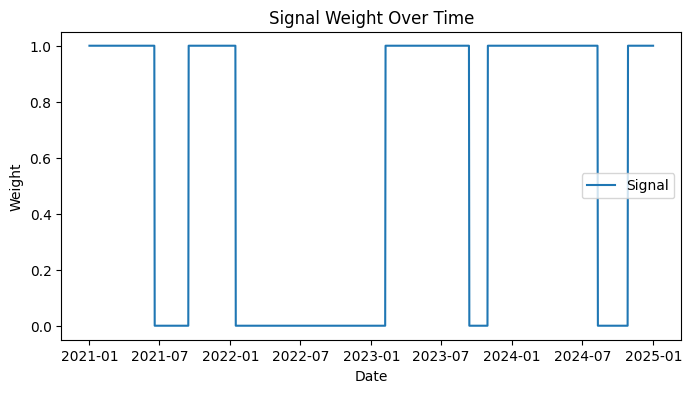

In [11]:
run_backtest(df)

## Death Cross Only

In [12]:
short = D['SMA_50'] < D['SMA_200']

df = pd.DataFrame(np.where(D['SMA_50']< D['SMA_200'], -1, 0), index=D.index, columns=['signal'])
#  & (D['Close'] > D['EMA_5'])

df

,signal
Timestamp,
2021-01-01,0
2021-01-02,0
2021-01-03,0
2021-01-04,0
2021-01-05,0
...,...
2024-12-27,0
2024-12-28,0
2024-12-29,0


Overall Annual Return: -7.88%
Overall Annual Sharpe Ratio: -0.2077
Maximum Drawdown: -58.74 %
Win/Loss Ratio: 0.9736
Alpha: 0.103
Beta: -0.3611

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.349226    0.341695    -0.162823     -0.211447      -1.022040
1  2022       0.772476    0.609175    -0.977934     -0.069074       1.268070
2  2023      -0.625370    0.216508    -0.210781     -0.401130      -2.888432
3  2024      -0.112911    0.198619    -0.141065      0.015248      -0.568482


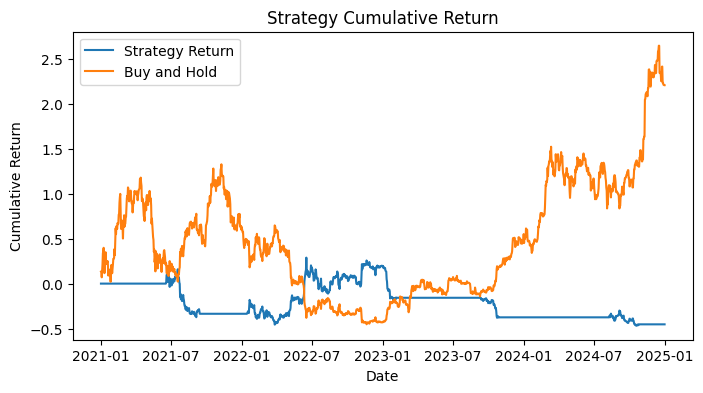

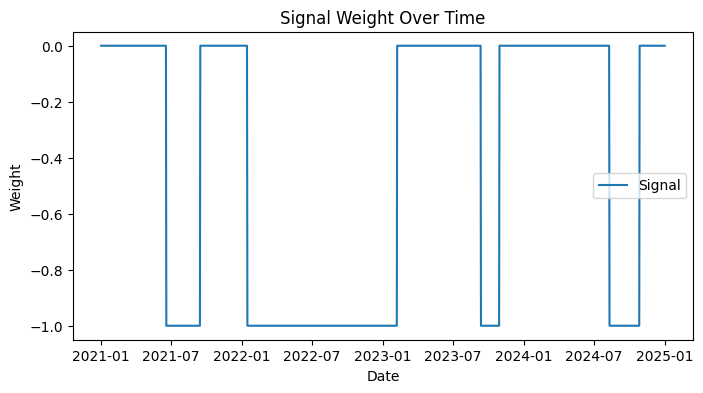

In [13]:
run_backtest(df)

## Golden & Death

In [70]:
# long = pd.DataFrame(np.where(temp['SMA_50'] > temp['SMA_200'], 1, 0))
# short = pd.DataFrame(np.where(temp['SMA_50'] < temp['SMA_200'], -1, 0))
# condition = long + short
# condition.columns = ['signal']
# condition.index = temp.index
# df = condition
# df


,signal
Date,
2021-01-01,1
2021-01-02,1
2021-01-03,1
2021-01-04,1
2021-01-05,1
...,...
2024-12-27,1
2024-12-28,1
2024-12-29,1


Overall Annual Return: 9.07%
Overall Annual Sharpe Ratio: 0.1465
Maximum Drawdown: -72.94 %
Win/Loss Ratio: 0.97
Alpha: 0.1836
Beta: 0.2251

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.209914    0.805634     0.643973     -0.433435      -0.260558
1  2022       0.573333    0.635267    -0.966222     -0.166464       0.902507
2  2023      -0.271357    0.443117     0.575577     -0.836546      -0.612382
3  2024       0.561039    0.535067     0.730579     -0.069892       1.048539


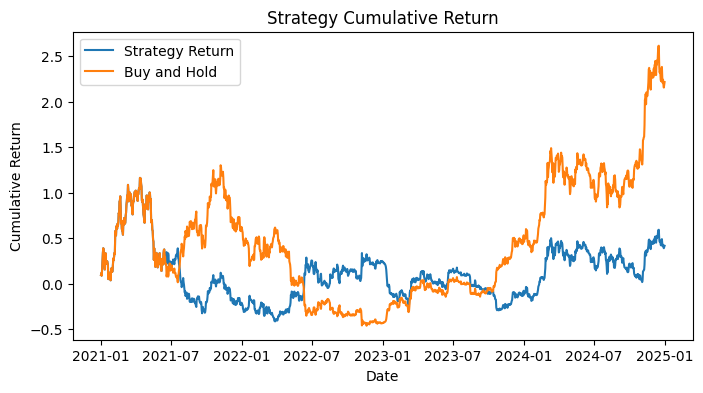

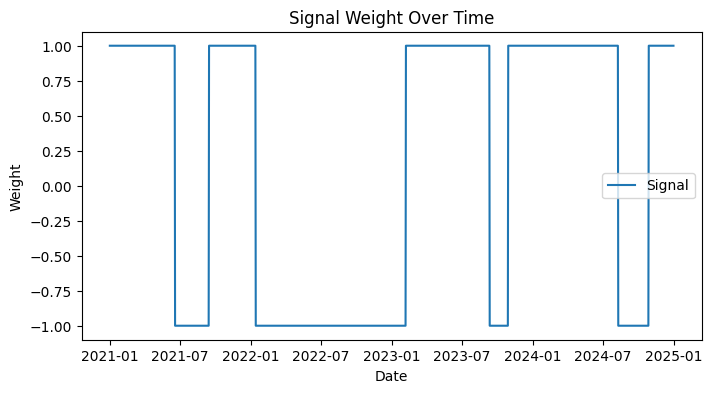

In [36]:
run_backtest(df)

# Fibonacci 5, 8, 13

## Long only

In [27]:
# Add 5, 8, 13 EMA 

# ema_5 = full['Close'].ewm(span=5, adjust=False).mean()
ema_8 = full['Close'].ewm(span=8, adjust=False).mean()
ema_13 = full['Close'].ewm(span=13, adjust=False).mean()

ema = pd.concat([D['Close'], D['EMA_5'], ema_8, ema_13], axis=1, keys=['Close','EMA_5', 'EMA_8', 'EMA_13'])
ema = ema.loc['2021-01-01':'2024-12-31']

ema

,Close,EMA_5,EMA_8,EMA_13
Timestamp,,,,
2021-01-01,29130.21,28082.640578,27241.135847,26036.368061
2021-01-02,33026.28,29730.520385,28526.723437,27034.926909
2021-01-03,32759.78,30740.273590,29467.402673,27852.763065
2021-01-04,31172.41,30884.319060,29846.293190,28326.998342
2021-01-05,33467.68,31745.439373,30651.045815,29061.381436
...,...,...,...,...
2024-12-27,94168.00,96804.979047,97422.960397,98076.896255
2024-12-28,94148.00,95919.319365,96695.191420,97515.625362
2024-12-29,93557.00,95131.879577,95997.815549,96950.107453


In [30]:
condition = ema[(ema['EMA_5'] > ema['EMA_8']) & 
                (ema['EMA_8'] > ema['EMA_13'])
                & (ema['Close'] > ema['EMA_5'])] # & (ema['Close'] > ema['EMA_5'])

df = pd.DataFrame(np.where(D.index.isin(condition.index), 1, 0), index = D.index, columns=['signal'])

Overall Annual Return: 34.38%
Overall Annual Sharpe Ratio: 0.9361
Maximum Drawdown: -41.73 %
Win/Loss Ratio: 1.0508
Alpha: 0.1949
Beta: 0.3383

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.766055    0.505327     0.357334      0.463684       1.515961
1  2022      -0.285993    0.248630     0.161796     -0.146761      -1.150276
2  2023       0.361502    0.314382     0.448496     -0.115631       1.149880
3  2024       0.533131    0.350739     0.440682      0.132764       1.520021


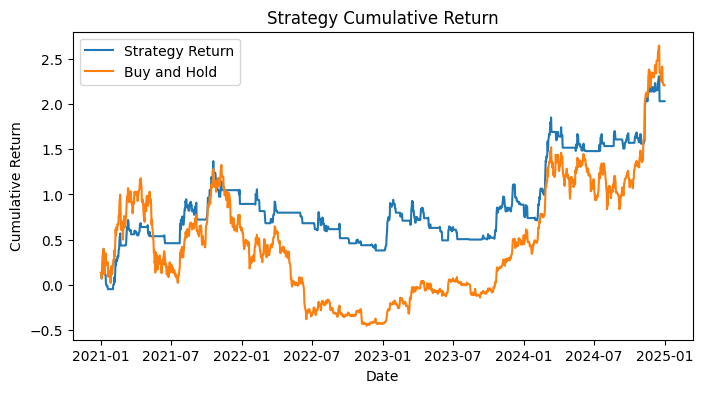

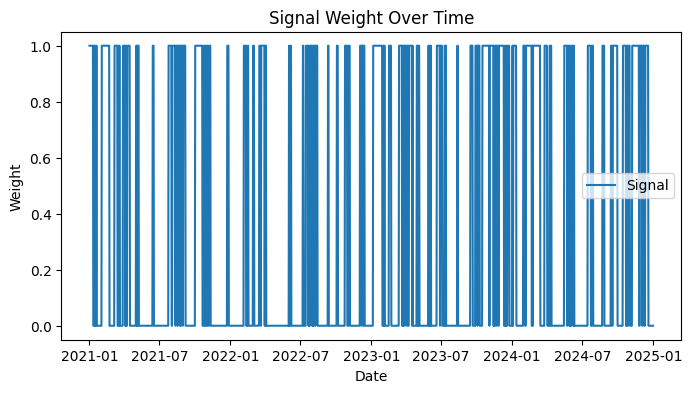

In [31]:
run_backtest(df)

## Short only

In [ ]:
condition = ema[(ema['EMA_5'] < ema['EMA_8']) & 
                (ema['EMA_8'] < ema['EMA_13']) & 
                (ema['Close'] < ema['EMA_5'])]

df = pd.DataFrame(np.where(D.index.isin(condition.index), -1, 0), index = D.index, columns=['signal'])

Overall Annual Return: -24.94%
Overall Annual Sharpe Ratio: -0.6399
Maximum Drawdown: -68.79 %
Win/Loss Ratio: 0.82
Alpha: -0.0188
Beta: -0.3963

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.351144    0.496153    -0.379660     -0.001775      -0.707733
1  2022      -0.127680    0.491599    -0.600130     -0.525806      -0.259724
2  2023      -0.207540    0.201491    -0.207411      0.010410      -1.030022
3  2024      -0.292173    0.283588    -0.280416     -0.052398      -1.030272


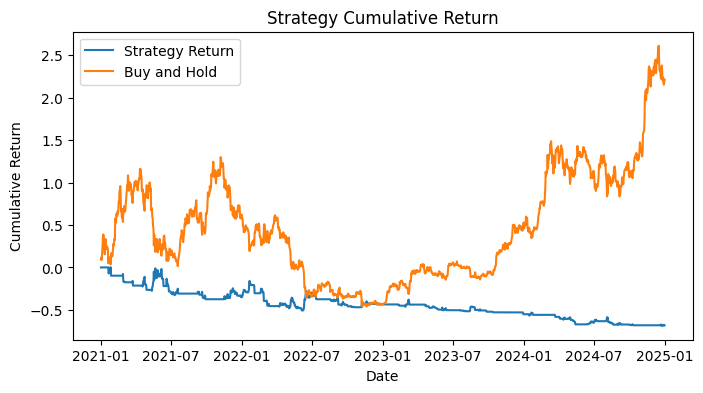

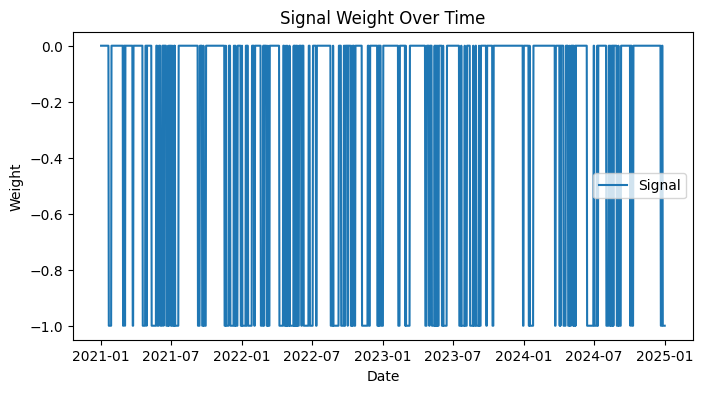

In [28]:
run_backtest(df)

## Long & Short 

In [40]:
long_condition = np.where((ema['EMA_5'] > ema['EMA_8']) & 
                (ema['EMA_8'] > ema['EMA_13']) & 
                (ema['Close'] > ema['EMA_5']), 1, 0)
short_condition = np.where((ema['EMA_5'] < ema['EMA_8']) & 
                (ema['EMA_8'] < ema['EMA_13']) & 
                (ema['Close'] < ema['EMA_5']), -1, 0)
condition = long_condition + short_condition

df = pd.DataFrame(condition, index = ema.index, columns=['signal'])


Overall Annual Return: 5.18%
Overall Annual Sharpe Ratio: 0.0994
Maximum Drawdown: -54.69 %
Win/Loss Ratio: 0.88
Alpha: 0.254
Beta: -0.0836

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.397609    0.679950    -0.047741      0.603035       0.584762
1  2022      -0.377721    0.549305    -0.452058     -0.707334      -0.687635
2  2023       0.167506    0.362895     0.257258     -0.056366       0.461584
3  2024       0.205029    0.440725     0.113691      0.181093       0.465210


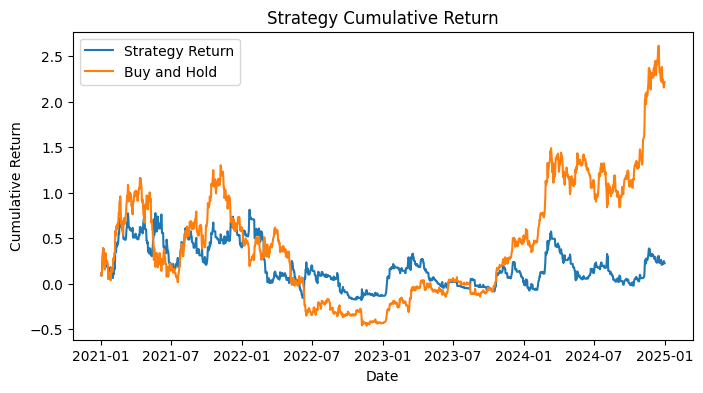

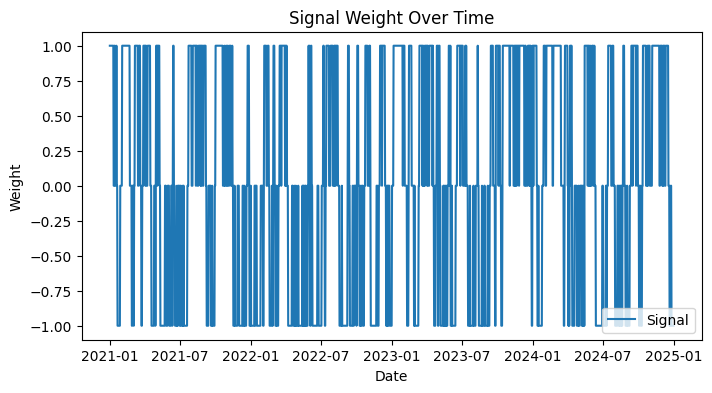

In [41]:
run_backtest(df)

# MACD + ADX

## Long ADX uptrend

In [12]:
# df = full.copy()
# # df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
# df = df.loc['2021-01-01':'2024-12-31']


macd = D[D['MACD_Histogram'] > 0]
adx = D[D['ADX'] > 25]
ema = D[(D['Close'] > D['EMA_5'])]

condition = D.index.isin(macd.index) & D.index.isin(adx.index) # & D.index.isin(ema.index)   

df = pd.DataFrame(np.where(condition, 1, 0), index = D.index, columns=['signal'])   

Overall Annual Return: 41.52%
Overall Annual Sharpe Ratio: 1.1919
Maximum Drawdown: -34.54 %
Win/Loss Ratio: 1.2056
Alpha: 0.3047
Beta: 0.3044

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.742377    0.502989     0.353973      0.442850       1.475932
1  2022       0.004332    0.295581     0.230382      0.202585       0.014656
2  2023       0.424196    0.261338     0.308714      0.095770       1.623174
3  2024       0.489560    0.277521     0.275109      0.239619       1.764047


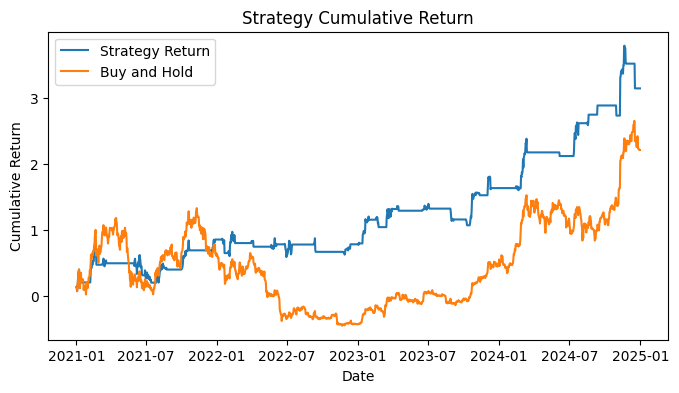

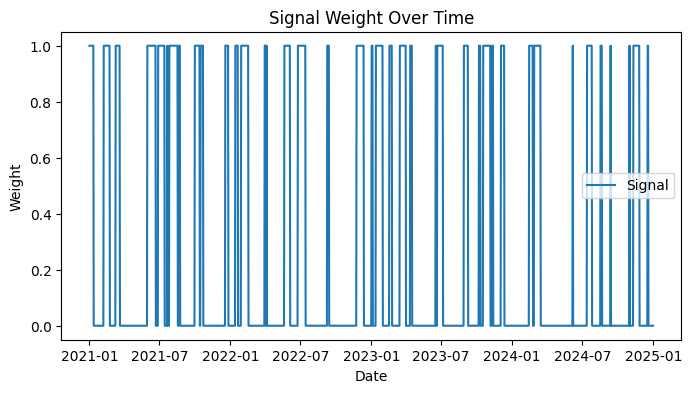

In [13]:
run_backtest(df)

## Short ADX downtrend

In [9]:
macd = D[D['MACD_histogram'] < 0]
adx = D[D['ADX'] > 25]

condition = D.index.isin(macd.index) & D.index.isin(adx.index)

df = pd.DataFrame(np.where(condition, -1, 0), index = D.index, columns=['signal'])

Overall Annual Return: -17.44%
Overall Annual Sharpe Ratio: -0.4266
Maximum Drawdown: -66.58 %
Win/Loss Ratio: 0.96
Alpha: 0.1085
Beta: -0.436

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.034625    0.520406    -0.418790      0.438411      -0.066534
1  2022       0.249281    0.443806    -0.487881     -0.093279       0.561688
2  2023      -0.369176    0.280877    -0.404192      0.013502      -1.314368
3  2024      -0.388737    0.349065    -0.425552     -0.047498      -1.113652


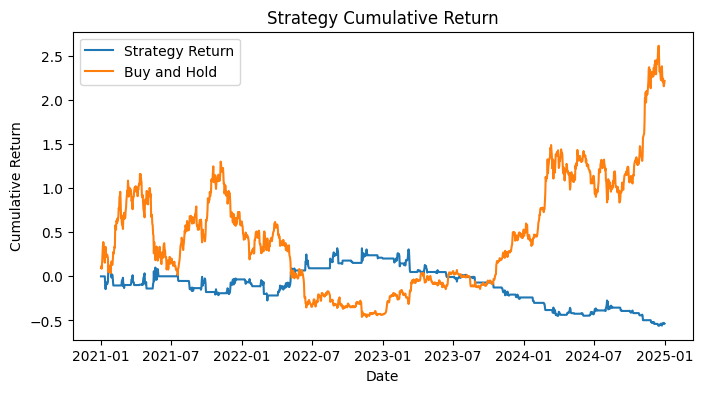

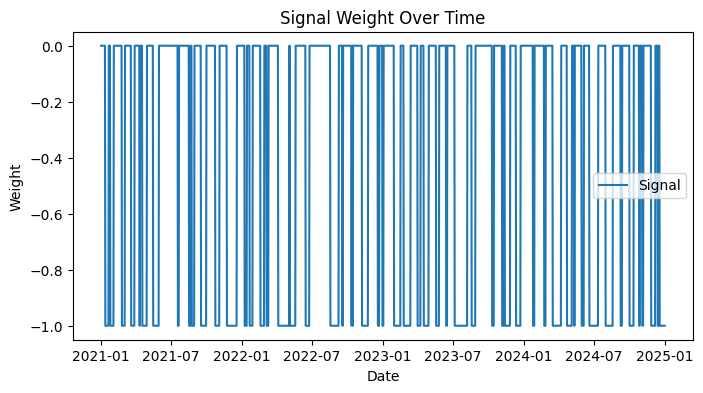

In [10]:
run_backtest(df)

## Long/short ADX with up/downtrend

In [13]:
bull = D[D['MACD_histogram'] > 0]
adx = D[D['ADX'] > 25]
long_condition = np.where(D.index.isin(bull.index) & D.index.isin(adx.index), 1, 0)

bear = D[D['MACD_histogram'] < 0]
short_condition = np.where(D.index.isin(bear.index) & D.index.isin(adx.index), -1, 0)

condition = long_condition + short_condition

df = pd.DataFrame(condition, index = D.index, columns=['signal'])
df


# macd = D[D['MACD_histogram'] > 0]
# adx = D[D['ADX'] > 25]
# condition = D.index.isin(macd.index) & D.index.isin(adx.index)

# df = pd.DataFrame(np.where(condition, 1, -1), index = D.index, columns=['signal'])
# df

,signal
Date,
2021-01-01,1
2021-01-02,1
2021-01-03,1
2021-01-04,1
2021-01-05,1
...,...
2024-12-27,-1
2024-12-28,-1
2024-12-29,-1


Overall Annual Return: 16.45%
Overall Annual Sharpe Ratio: 0.2972
Maximum Drawdown: -45.67 %
Win/Loss Ratio: 0.97
Alpha: 0.4052
Beta: -0.0736

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       1.215126    0.721044    -0.032573      1.079573       1.685231
1  2022      -0.269213    0.565120    -0.187273     -0.312484      -0.476381
2  2023       0.111533    0.392837    -0.025245      0.209639       0.283915
3  2024       0.022207    0.481146    -0.047349      0.180075       0.046154


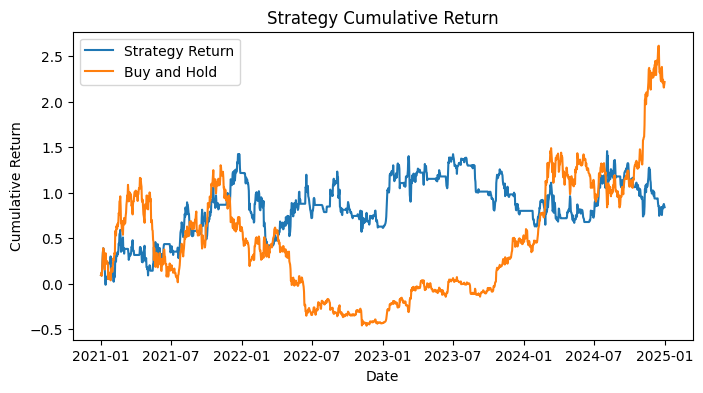

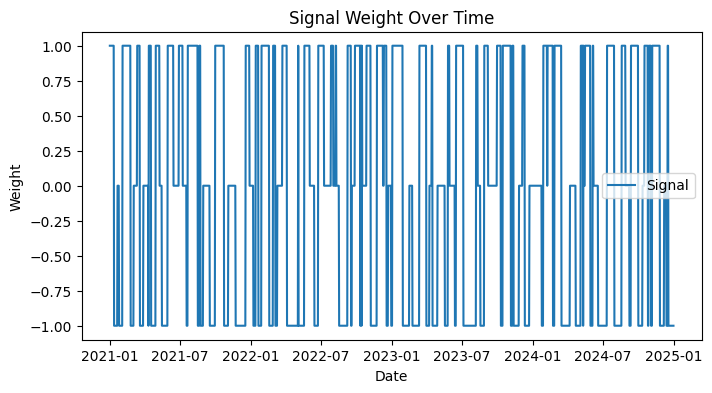

In [14]:
run_backtest(df)

In [56]:
df = pd.DataFrame(np.where(D['SMA_10']>D['SMA_50'], 1, -1))
df.columns = ['signal']
df.index = D.index

df.head()

,signal
Date,
2021-01-01,1
2021-01-02,1
2021-01-03,1
2021-01-04,1
2021-01-05,1


Overall Annual Return: 15.72%
Overall Annual Sharpe Ratio: 0.2539
Maximum Drawdown: -60.27 %
Win/Loss Ratio: 1.0
Alpha: 0.3944
Beta: 0.0101

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.645705    0.804500     0.067468      0.765451       0.802617
1  2022      -0.095087    0.636168    -0.422625     -0.255592      -0.149469
2  2023       0.384648    0.442710     0.254358      0.150151       0.868850
3  2024      -0.129745    0.535951     0.321364     -0.284334      -0.242084


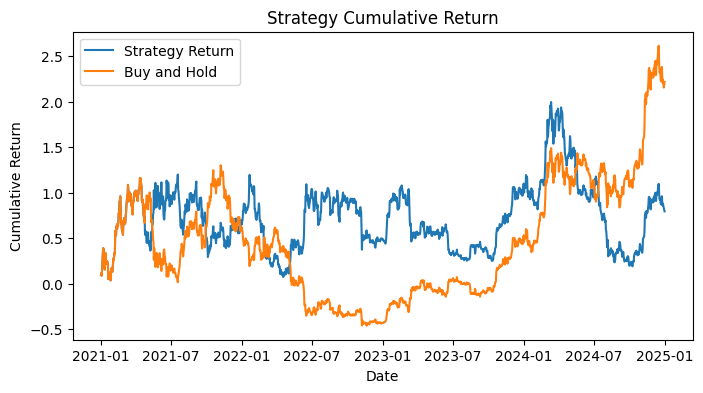

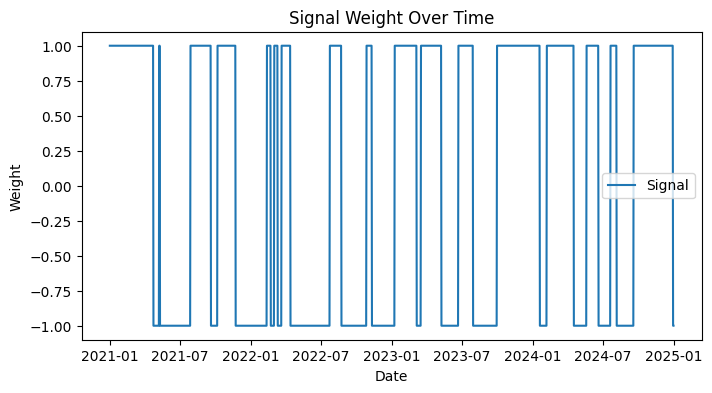

In [57]:
run_backtest(df)

In [64]:
df = pd.DataFrame(np.where(D['EMA_10']>D['EMA_50'], 1, -1))
df.columns = ['signal']
df.index = D.index

df.head()

,signal
Date,
2021-01-01,1
2021-01-02,1
2021-01-03,1
2021-01-04,1
2021-01-05,1


Overall Annual Return: 15.65%
Overall Annual Sharpe Ratio: 0.2529
Maximum Drawdown: -65.41 %
Win/Loss Ratio: 1.01
Alpha: 0.38
Beta: 0.031

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.678946    0.804440     0.214656      0.667660       0.843999
1  2022      -0.177001    0.636191    -0.711318     -0.594708      -0.278220
2  2023       0.262762    0.442926     0.414685     -0.114485       0.593242
3  2024       0.025689    0.535878     0.397143     -0.188519       0.047938


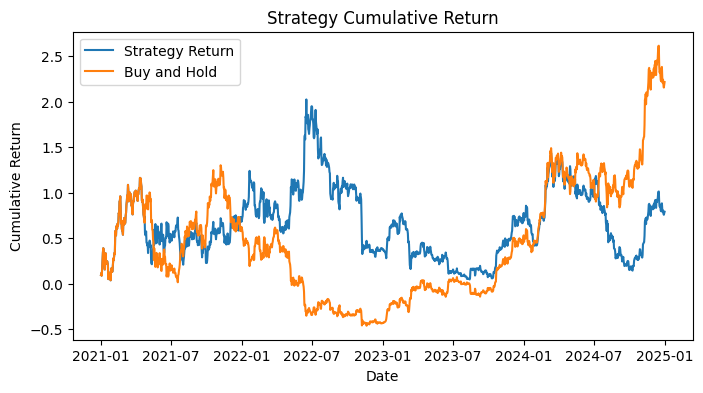

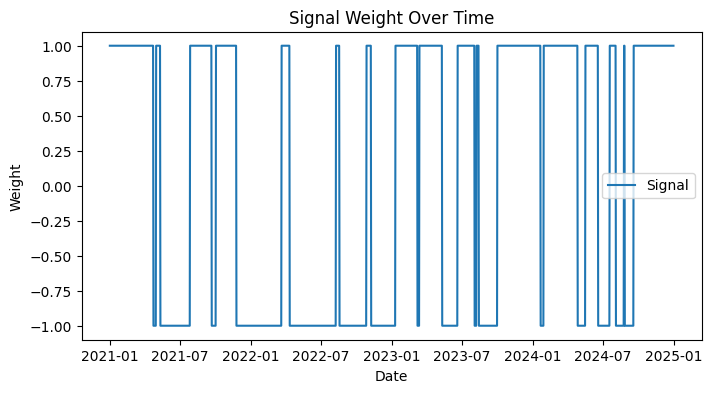

In [65]:
run_backtest(df)

Overall Annual Return: -31.23%
Overall Annual Sharpe Ratio: -0.5043
Maximum Drawdown: -92.74 %
Win/Loss Ratio: 0.91
Alpha: -0.1797
Beta: 0.0338

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.572763    0.805176     0.073017     -0.584197      -0.711351
1  2022      -0.517208    0.635597    -0.283761     -0.765111      -0.813735
2  2023      -0.239104    0.443171     0.218442     -0.409211      -0.539530
3  2024       0.422632    0.535322     0.262170      0.259699       0.789491


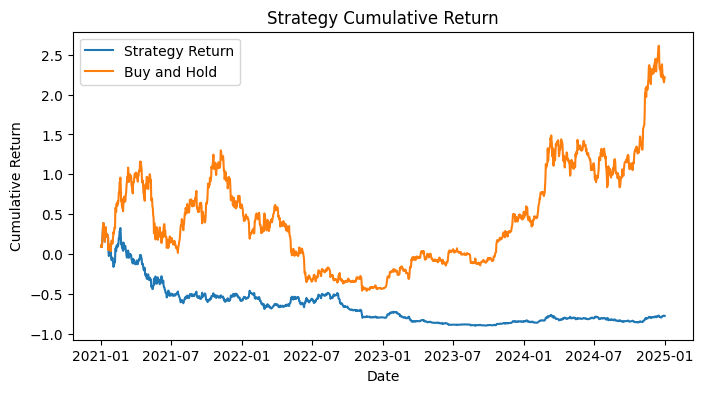

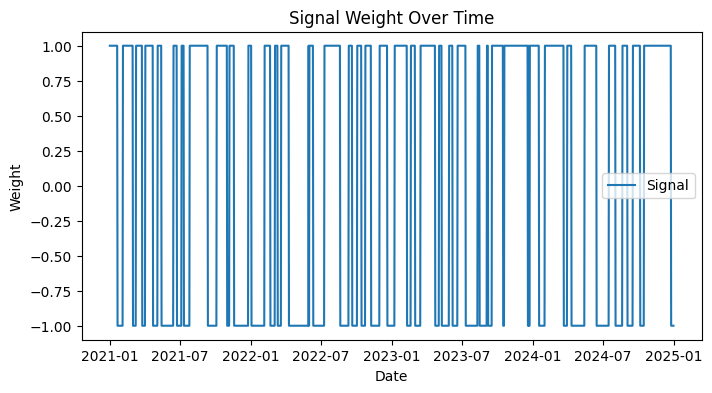

In [70]:
df = pd.DataFrame(np.where(D['SMA_10']>D['SMA_20'], 1, -1))
df.columns = ['signal']
df.index = temp.index

run_backtest(df)

Overall Annual Return: 15.65%
Overall Annual Sharpe Ratio: 0.2529
Maximum Drawdown: -65.41 %
Win/Loss Ratio: 1.01
Alpha: 0.38
Beta: 0.031

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.678946    0.804440     0.214656      0.667660       0.843999
1  2022      -0.177001    0.636191    -0.711318     -0.594708      -0.278220
2  2023       0.262762    0.442926     0.414685     -0.114485       0.593242
3  2024       0.025689    0.535878     0.397143     -0.188519       0.047938


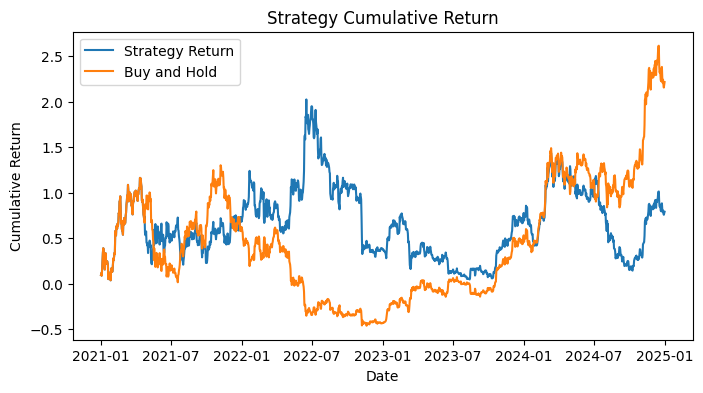

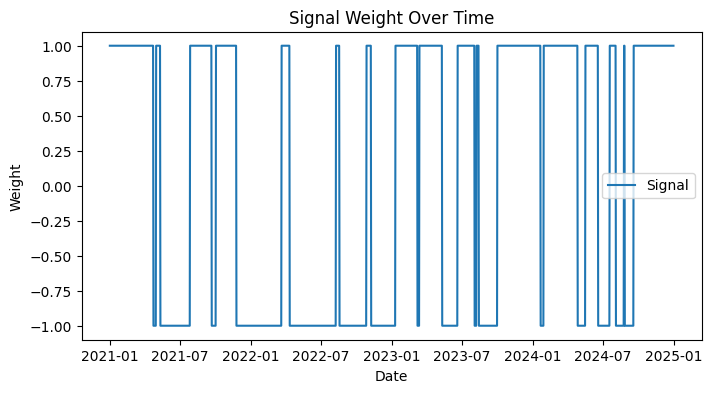

In [71]:
df = pd.DataFrame(np.where(D['EMA_10']>D['EMA_50'], 1, -1))
df.columns = ['signal']
df.index = temp.index

run_backtest(df)

# SMA + RSI

## Long 

In [34]:
# Bull market when RSI_14 > 50
# Long when SMA_5 > SMA_50 and close > EMA_5

df = full.copy()
# df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df = df.loc['2021-01-01':'2024-12-31']

bull = df[df['RSI_14']>40]
long = df[(df['SMA_5'] > df['SMA_50'])   & (df['Close'] > df['EMA_5'])] # & (df['Close'] > df['EMA_5'])

condition = df.index.isin(bull.index) & df.index.isin(long.index) 

df = pd.DataFrame(np.where(condition, 1, 0), index = df.index, columns=['signal'])

Overall Annual Return: 48.46%
Overall Annual Sharpe Ratio: 1.341
Maximum Drawdown: -35.14 %
Win/Loss Ratio: 1.1491
Alpha: 0.3825
Beta: 0.3278

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.896552    0.500700     0.351227      0.599348       1.790595
1  2022      -0.225035    0.170112     0.075263     -0.160268      -1.322857
2  2023       0.632232    0.325976     0.482186      0.119258       1.939506
3  2024       0.634307    0.368169     0.486029      0.192741       1.722869


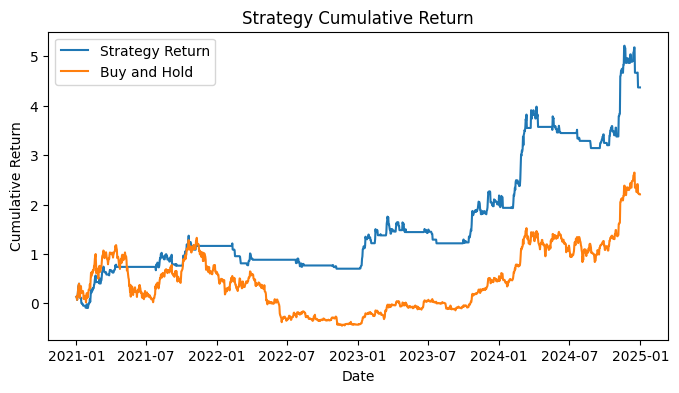

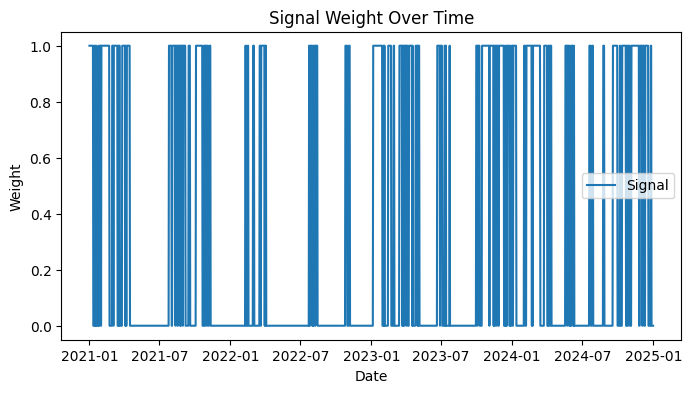

In [35]:
run_backtest(df)

## Short

In [12]:
# Bear market when RSI_14 < 50
# Short when EMA_5 < EMA_60 and close < EMA_5

df = full.copy()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA_60'] = df['Close'].ewm(span=60, adjust=False).mean()
df = df.loc['2021-01-01':'2024-12-31']

bear = df[df['RSI_14']<50]
short = df[(df['EMA_5'] < df['EMA_60']) # & (df['Close'] < df['EMA_5']
] #  
condition = df.index.isin(bear.index) & df.index.isin(short.index)

df = pd.DataFrame(np.where(condition, -1, 0), index = df.index, columns=['signal'])

Overall Annual Return: -13.93%
Overall Annual Sharpe Ratio: -0.337
Maximum Drawdown: -60.21 %
Win/Loss Ratio: 0.95
Alpha: 0.1634
Beta: -0.4464

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.077093    0.494635    -0.378142      0.347619      -0.155859
1  2022       0.145532    0.565117    -0.791809     -0.377287       0.257525
2  2023      -0.277688    0.210555    -0.226014     -0.060052      -1.318838
3  2024      -0.281152    0.276751    -0.267014     -0.050860      -1.015903


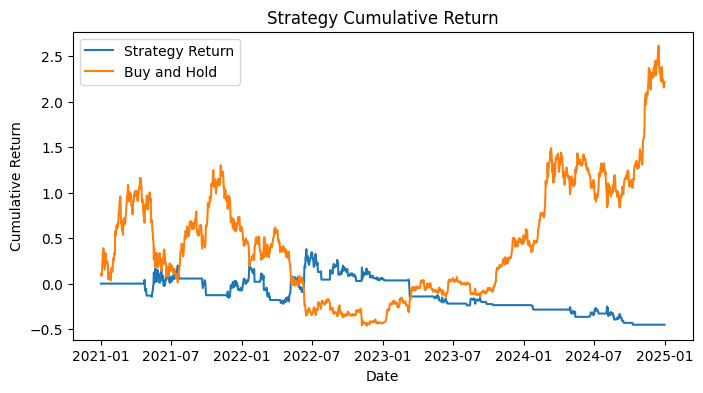

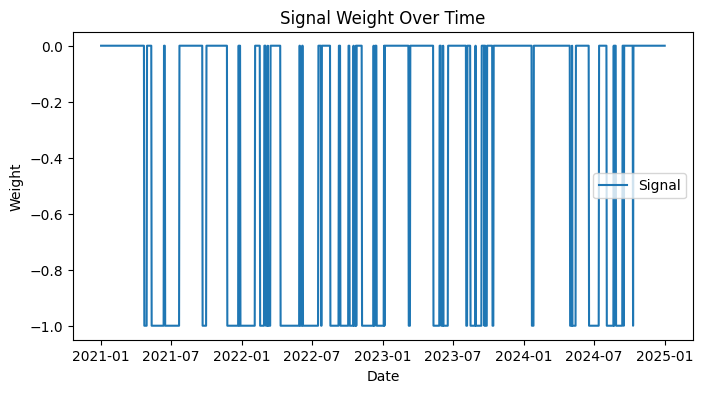

In [13]:
run_backtest(df)

## Long Short

In [120]:
# 2 conditions

df = full.copy()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA_60'] = df['Close'].ewm(span=60, adjust=False).mean()
df = df.loc['2021-01-01':'2024-12-31']

bull = df[df['RSI_14']>50]
long = df[(df['EMA_5'] > df['EMA_60']) & (df['Close'] > df['EMA_5'])]
long_condition = np.where(df.index.isin(bull.index) & df.index.isin(long.index), 1, 0)

bear = df[df['RSI_14']<50]
short = df[(df['EMA_5'] < df['EMA_60']) & (df['Close'] < df['EMA_5'])]
short_condition = np.where(df.index.isin(bear.index) & df.index.isin(short.index), -1, 0)

condition = long_condition + short_condition
df = pd.DataFrame(condition, index = df.index, columns=['signal'])

Overall Annual Return: 25.11%
Overall Annual Sharpe Ratio: 0.5007
Maximum Drawdown: -48.65 %
Win/Loss Ratio: 0.91
Alpha: 0.4587
Beta: -0.0596

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.880158    0.643127     0.030024      0.812212       1.368560
1  2022      -0.125616    0.524246    -0.613922     -0.518576      -0.239613
2  2023       0.173512    0.359329     0.374636     -0.178695       0.482877
3  2024       0.269978    0.435633     0.218262      0.137160       0.619738


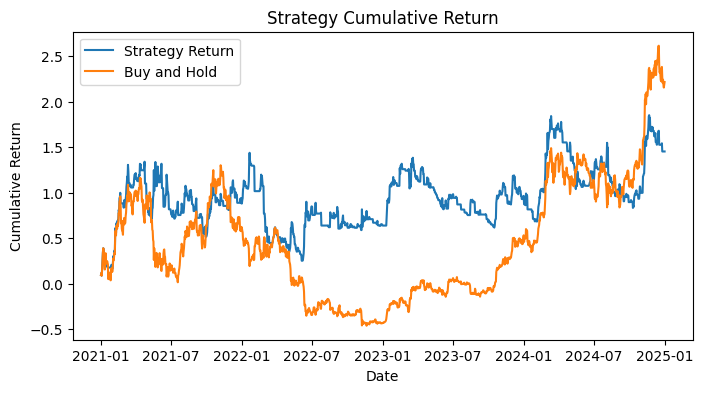

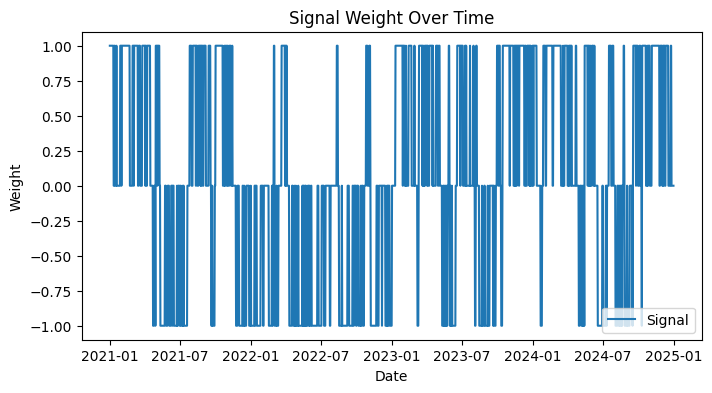

In [121]:
run_backtest(df)

Overall Annual Return: 38.39%
Overall Annual Sharpe Ratio: 0.6205
Maximum Drawdown: -56.22 %
Win/Loss Ratio: 0.99
Alpha: 1.0336
Beta: -0.4041

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       1.364051    0.803265    -0.331948      1.449014       1.698134
1  2022       0.593327    0.635231    -0.932617     -0.125162       0.934033
2  2023      -0.235158    0.443175     0.032882     -0.205955      -0.530621
3  2024       0.273562    0.535572    -0.123078      0.495487       0.510785


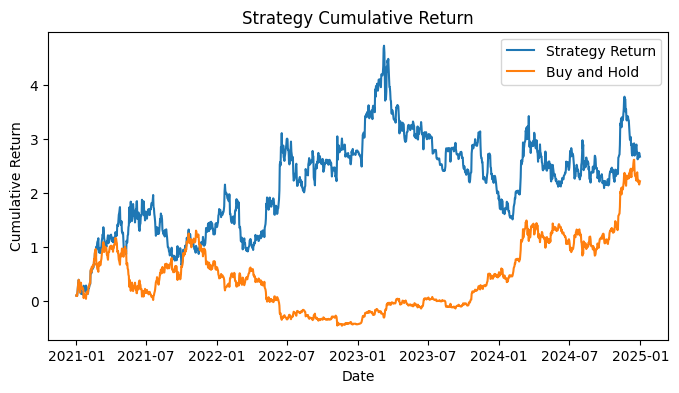

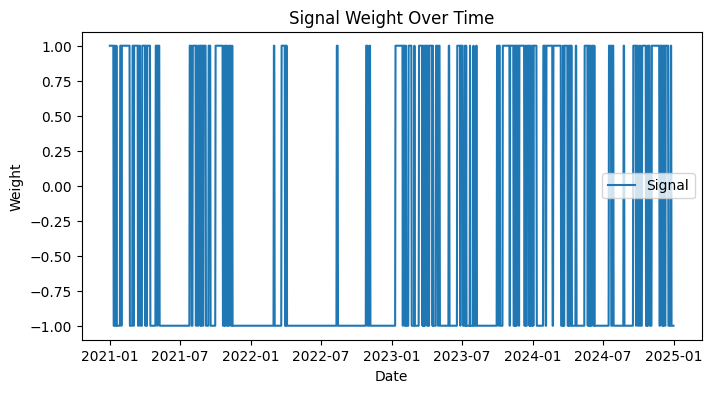

In [50]:
# Complete Opposite

df = full.copy()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA_60'] = df['Close'].ewm(span=60, adjust=False).mean()
df = df.loc['2021-01-01':'2024-12-31']

bull = df[df['RSI_14']>50]
long = df[(df['EMA_5'] > df['EMA_60']) & (df['Close'] > df['EMA_5'])]
condition = np.where(df.index.isin(bull.index) & df.index.isin(long.index), 1, -1)

df = pd.DataFrame(condition, index = df.index, columns=['signal'])

run_backtest(df)

# MACD + RSI

## Long

In [36]:
df = full.copy()
# df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df = df.loc['2021-01-01':'2024-12-31']

rsi = df[(df['RSI_14'] > 40)]
macd = df[(df['MACD_Histogram'] > 0)]
ema = df[(df['Close'] > df['EMA_5'])]

condition = np.where((D.index.isin(macd.index)) 
                     & (D.index.isin(rsi.index))  
                     & (D.index.isin(ema.index)) , 1, 0) # & (D.index.isin(ema.index))

df = pd.DataFrame(condition, index = D.index, columns=['signal'])

Overall Annual Return: 32.67%
Overall Annual Sharpe Ratio: 0.9024
Maximum Drawdown: -46.01 %
Win/Loss Ratio: 1.0588
Alpha: 0.1802
Beta: 0.3288

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.744326    0.484080     0.327842      0.466910       1.537611
1  2022      -0.458701    0.311611     0.254682     -0.239538      -1.472033
2  2023       0.524508    0.294346     0.392393      0.107061       1.781947
3  2024       0.496351    0.324254     0.376310      0.154466       1.530744


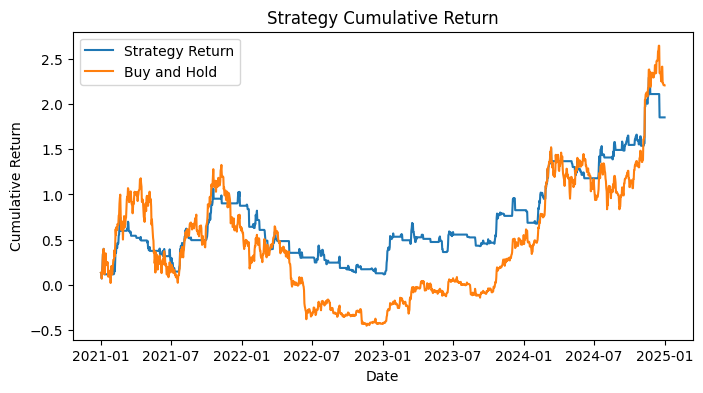

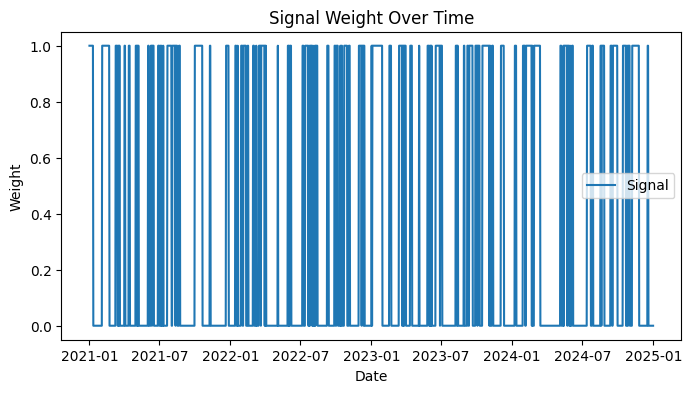

In [37]:
run_backtest(df)

## Short

In [93]:
df = full.copy()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df = df.loc['2021-01-01':'2024-12-31']
rsi = df[(df['RSI_14'] < 50)]
macd = df[(df['MACD_histogram'] < 0)]
ema = df[(df['Close'] < df['EMA_5'])]

condition = np.where((D.index.isin(macd.index)) & 
                     (D.index.isin(rsi.index)) & 
                     (D.index.isin(ema.index)), -1, 0)

df = pd.DataFrame(condition, index = D.index, columns=['signal'])

Overall Annual Return: -17.01%
Overall Annual Sharpe Ratio: -0.4704
Maximum Drawdown: -53.34 %
Win/Loss Ratio: 0.83
Alpha: 0.0449
Beta: -0.3411

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021      -0.276856    0.446014    -0.306778      0.023791      -0.620733
1  2022      -0.003079    0.456216    -0.516258     -0.338402      -0.006750
2  2023      -0.154833    0.181450    -0.168323      0.029004      -0.853312
3  2024      -0.221308    0.289706    -0.293084      0.056187      -0.763906


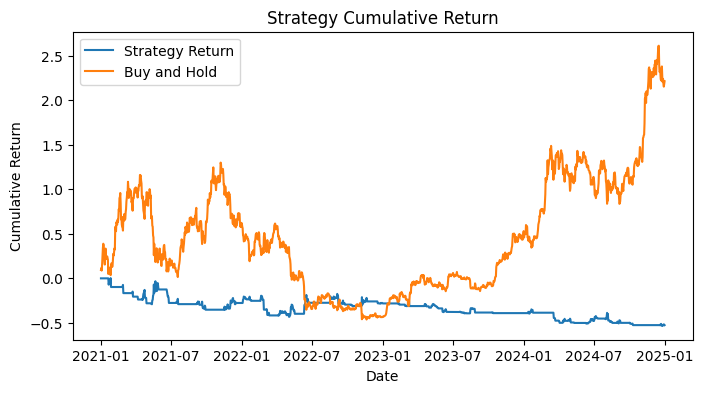

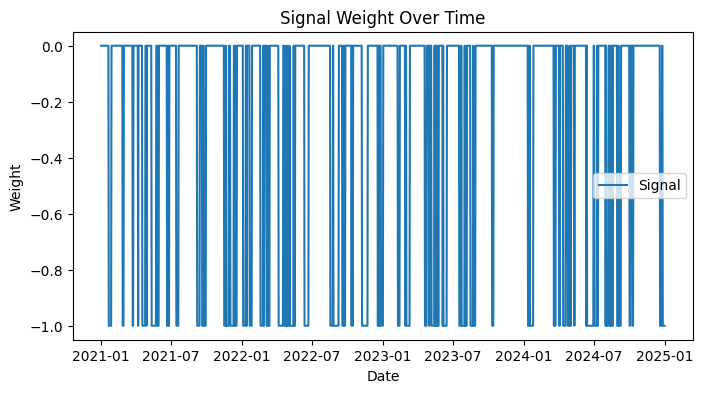

In [94]:
run_backtest(df)

## Long Short

In [131]:
df = full.copy()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df = df.loc['2021-01-01':'2024-12-31']

rsi_long = df[(df['RSI_14'] > 50)]
macd_long = df[(df['MACD_histogram'] > 0)]
ema_long = df[(df['Close'] > df['EMA_5'])]

long_condition =np.where((D.index.isin(rsi_long.index)) &
                        (D.index.isin(macd_long.index)) &
                        (D.index.isin(ema_long.index)), 1, 0)

rsi_short = df[(df['RSI_14'] < 50)]
macd_short = df[(df['MACD_histogram'] < 0)]
ema_short = df[(df['Close'] < df['EMA_5'])]

short_condition = np.where((D.index.isin(rsi_short.index)) &
                        (D.index.isin(macd_short.index)) &
                        (D.index.isin(ema_short.index)), -1, 0)

condition = long_condition + short_condition
df = pd.DataFrame(condition, index = df.index, columns=['signal'])

Overall Annual Return: 14.92%
Overall Annual Sharpe Ratio: 0.31
Maximum Drawdown: -41.26 %
Win/Loss Ratio: 0.9
Alpha: 0.3391
Beta: -0.0783

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.463840    0.621423    -0.019057      0.587968       0.746416
1  2022      -0.286178    0.509151    -0.390934     -0.539925      -0.562069
2  2023       0.448414    0.326529     0.206349      0.201440       1.373271
3  2024       0.152568    0.419454     0.026045      0.206407       0.363729


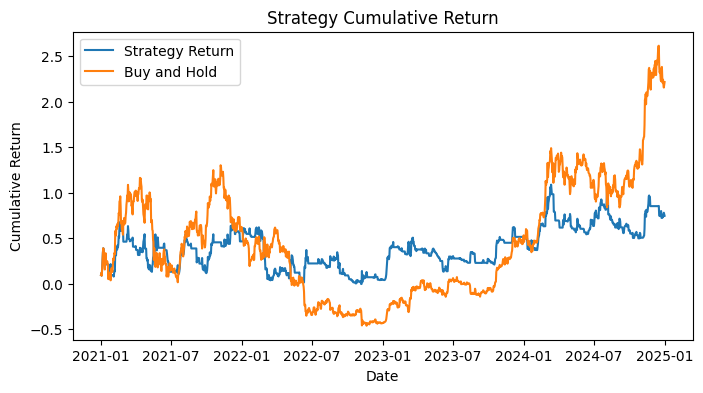

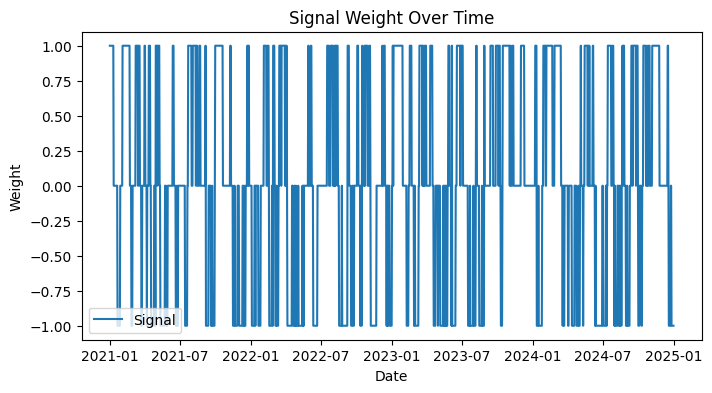

In [132]:
run_backtest(df)

# Testing

In [104]:
df = full.copy()
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df = df.loc['2021-01-01':'2024-12-31']

rsi_long = df[(df['RSI_14'] > 40)]
macd_long = df[(df['MACD_histogram'] > 0)]
sma_long = df[(df['Close'] > df['SMA_50'])]

condition =np.where((D.index.isin(rsi_long.index)) &
                        (D.index.isin(macd_long.index)) &
                        (D.index.isin(sma_long.index)), 1, 0)

df = pd.DataFrame(condition, index = df.index, columns=['signal'])

Overall Annual Return: 29.72%
Overall Annual Sharpe Ratio: 0.8963
Maximum Drawdown: -39.15 %
Win/Loss Ratio: 0.97
Alpha: 0.1924
Beta: 0.2868

Yearly Metrics:
   year  yearly_return  yearly_std  yearly_beta  yearly_alpha  yearly_sharpe
0  2021       0.734749    0.455855     0.320615      0.394011       1.611804
1  2022      -0.310905    0.242603     0.144950     -0.218908      -1.281540
2  2023       0.889472    0.270419     0.374436      0.270428       3.289241
3  2024       0.253853    0.314884     0.346220     -0.036182       0.806180


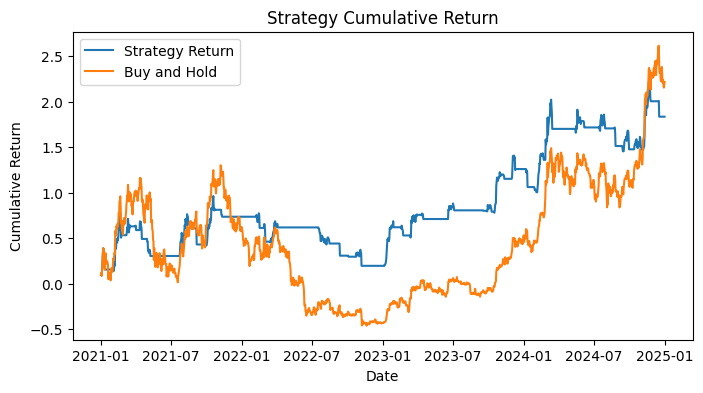

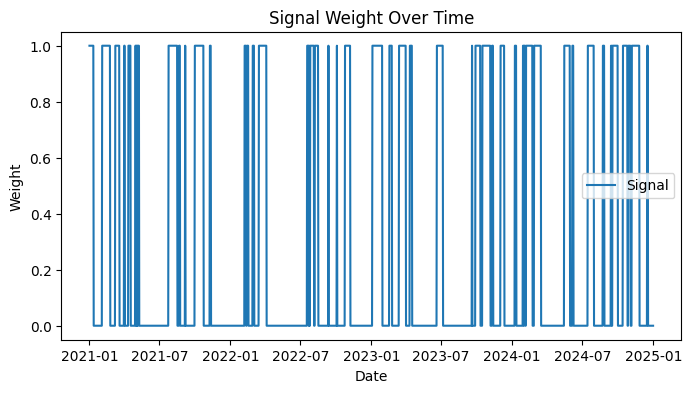

In [105]:
run_backtest(df)